Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

Load Data

In [3]:
traders = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

Preview Data

In [6]:
traders.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


Date Conversion


In [7]:
traders['date'] = pd.to_datetime(
    traders['Timestamp'],
    unit='ms'
).dt.date

sentiment['date'] = pd.to_datetime(
    sentiment['date']
).dt.date

Merge


In [8]:
merged = pd.merge(
    traders,
    sentiment,
    on='date',
    how='inner'
)

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,1730007000,74,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,1730007000,74,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,1730007000,74,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,1730007000,74,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,1730007000,74,Greed


Avg Profit Analysis

In [9]:
avg_pnl = merged.groupby('classification')['Closed PnL'].mean()

avg_pnl

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64

Trade Count

In [10]:
trade_count = merged.groupby('classification')['Account'].count()

trade_count

classification
Extreme Greed      6962
Fear             133871
Greed             36289
Neutral            7141
Name: Account, dtype: int64

Top Traders

In [11]:
top_traders = merged.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False)

top_traders.head(10)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.040922e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401572e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.111830e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.744040e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.258152e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    4.035016e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.936830e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.615766e+05
Name: Closed PnL, dtype: float64

Chart

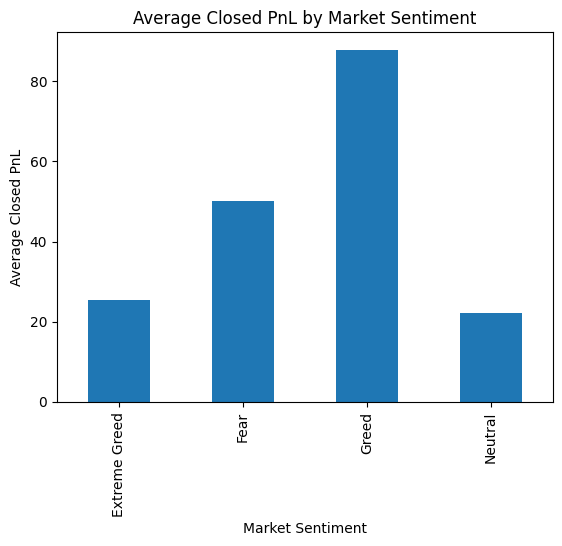

In [12]:
avg_pnl.plot(kind='bar')

plt.title("Average Closed PnL by Market Sentiment")

plt.xlabel("Market Sentiment")

plt.ylabel("Average Closed PnL")

plt.show()

# Conclusion

1. Traders achieved highest profitability during Greed sentiment.
2. Most trading activity occurred during Fear periods.
3. Trading frequency and profitability showed different behavioral trends.
4. Market sentiment influences trader behavior and outcomes.